In [2]:
import math
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import spikegen
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np

In [3]:
def print_batch_accuracy(data, targets, train=False):
    output, _, _, _ = net(data.view(batch_size, -1))
    _, idx = output.sum(dim=0).max(1)
    acc = np.mean((targets == idx).detach().cpu().numpy())

    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")

def train_printer(
    data, targets, epoch,
    counter, iter_counter,
        loss_hist, test_loss_hist, test_data, test_targets):
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[counter]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[counter]:.2f}")
    print_batch_accuracy(data, targets, train=True)
    print_batch_accuracy(test_data, test_targets, train=False)
    print("\n")

In [4]:
batch_size = 128
data_path='/tmp/data/mnist'

dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
## DATA PREP
# Define a transform
transform = transforms.Compose([
            transforms.Resize((28, 28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)
# Create DataLoaders
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)

100.0%
100.0%
100.0%
100.0%


In [ ]:
class STDPPlasticity:
    """
    Pair-based STDP with decaying pre/post traces.
    Updates a given weight matrix W in-place (shape: [out_features, in_features]).
    """
    def __init__(
        self,
        weight: torch.Tensor,
        tau_pre: float = 20.0,
        tau_post: float = 20.0,
        A_plus: float = 0.020,
        A_minus: float = 0.021,
        lr: float = 1e-4,
        wmin: float | None = None,
        wmax: float | None = None,
        dt: float = 1.0, # = time pre_synap spike - time pos_synap spike
    ):
        self.W = weight
        self.A_plus = A_plus
        self.A_minus = A_minus
        self.lr = lr
        self.wmin = wmin
        self.wmax = wmax

        self.decay_pre = math.exp( -dt / tau_pre)
        self.decay_post = math.exp( -dt / tau_post)

        self.pre_trace = None    # (B, in_features)
        self.post_trace = None   # (B, out_features)

    def reset_state(self):
        self.pre_trace = None
        self.post_trace = None

    @torch.no_grad()
    def step(self, pre_spk: torch.Tensor, post_spk: torch.Tensor):
        """
        pre_spk:  (Batch_size(B), in_features) spikes (0/1 or float in [0,1])
        post_spk: (Batch_size(B), out_features)
        we do the no_grad here because weights are manually calculated
        this is used to calculate the weight changes
        """
        B, in_features = pre_spk.shape
        _, out_features = post_spk.shape

        device = pre_spk.device
        dtype = self.W.dtype

        if self.pre_trace is None:
            self.pre_trace = torch.zeros((B, in_features), device=device, dtype=dtype)
            self.post_trace = torch.zeros((B, out_features), device=device, dtype=dtype)

        pre = pre_spk.to(dtype)
        post = post_spk.to(dtype)

        # Decay traces + add current spikes
        self.pre_trace.mul_(self.decay_pre).add_(pre)
        self.post_trace.mul_(self.decay_post).add_(post)

        # STDP correlations
        pot = post.T @ self.pre_trace            # (out, in)
        dep = self.post_trace.T @ pre            # (out, in)
        # devided by B cause this is batch calculation
        dW = (self.A_plus * pot - self.A_minus * dep) / B
        self.W.add_(self.lr * dW)

        if self.wmin is not None or self.wmax is not None:
            lo = self.wmin if self.wmin is not None else -float("inf")
            hi = self.wmax if self.wmax is not None else float("inf")
            self.W.clamp_(lo, hi)


class SNN_STDP(nn.Module):
    def __init__(self, layer_num, beta, step_num, hidden_num, num_inputs, num_outputs,
                 stdp_lr=1e-4, tau_pre=20.0, tau_post=20.0, A_plus=0.010, A_minus=0.012, 
                 wmin=None, wmax=None):
        super().__init__()
        self.layer_num = layer_num
        self.beta = beta
        self.step_num = step_num
        self.hidden_num = hidden_num

        # 1. Initialize Layers
        self.inputFC = nn.Linear(num_inputs, self.hidden_num)
        self.inputLIF = snn.Leaky(beta=self.beta)

        self.innerLayer = nn.ModuleList()
        self.innerLIF = nn.ModuleList()
        for _ in range(layer_num):
            self.innerLayer.append(nn.Linear(self.hidden_num, self.hidden_num))
            self.innerLIF.append(snn.Leaky(beta=self.beta))

        self.outputFC = nn.Linear(self.hidden_num, num_outputs)
        self.outputLIF = snn.Leaky(beta=self.beta)

        # 2. Centralized STDP Tracker
        # We store all STDP handlers in a single list matching the flow of data
        self.stdp_modules = []
        
        # Helper dictionary for STDP kwargs
        stdp_kwargs = {
            'tau_pre': tau_pre, 'tau_post': tau_post, 'A_plus': A_plus, 
            'A_minus': A_minus, 'lr': stdp_lr, 'wmin': wmin, 'wmax': wmax
        }

        # Add Input STDP
        self.stdp_modules.append(STDPPlasticity(self.inputFC.weight, **stdp_kwargs))
        
        # Add Inner Layers STDP
        for i in range(layer_num):
            self.stdp_modules.append(STDPPlasticity(self.innerLayer[i].weight, **stdp_kwargs))
            
        # Add Output STDP
        self.stdp_modules.append(STDPPlasticity(self.outputFC.weight, **stdp_kwargs))


    def apply_stdp(self, all_pre_spks, all_post_spks):
        """
        Loops through the collected spikes and applies STDP layer-by-layer.
        all_pre_spks:  List of tensors, one per layer. Shape of each: (T, B, in_features)
        all_post_spks: List of tensors, one per layer. Shape of each: (T, B, out_features)
        """
        with torch.no_grad():
            for layer_idx, stdp_mod in enumerate(self.stdp_modules):
                # Reset traces at the start of a new sequence/batch
                stdp_mod.reset_state()
                
                # Get the sequence of spikes for this specific layer
                pre_seq = all_pre_spks[layer_idx]
                post_seq = all_post_spks[layer_idx]
                
                # Apply STDP step-by-step through time
                for t in range(pre_seq.size(0)):
                    stdp_mod.step(pre_seq[t], post_seq[t])


    def forward(self, x):
        # Initialize hidden states
        mem_in = self.inputLIF.init_leaky()
        mem_hidden = [layer.init_leaky() for layer in self.innerLIF]
        mem_out = self.outputLIF.init_leaky()

        # We have 1 Input + N Hidden + 1 Output layers mapping weights
        total_weight_layers = self.layer_num + 2 
        
        # Setup recording lists for each weight layer
        pre_spk_rec = [[] for _ in range(total_weight_layers)]
        post_spk_rec = [[] for _ in range(total_weight_layers)]
        
        spk_out_rec = []
        mem_out_rec = []

        for _ in range(self.step_num):
            layer_idx = 0
            
            # --- INPUT LAYER ---
            pre_spk_rec[layer_idx].append(x)  # Pre-synaptic to Input layer
            
            cur = self.inputFC(x)
            spk_in, mem_in = self.inputLIF(cur, mem_in)
            
            post_spk_rec[layer_idx].append(spk_in) # Post-synaptic from Input layer
            prev_spk = spk_in
            layer_idx += 1

            # --- INNER LAYERS ---
            for idx in range(self.layer_num):
                pre_spk_rec[layer_idx].append(prev_spk)
                
                cur = self.innerLayer[idx](prev_spk)
                spk_hid, mem_hidden[idx] = self.innerLIF[idx](cur, mem_hidden[idx])
                
                post_spk_rec[layer_idx].append(spk_hid)
                prev_spk = spk_hid
                layer_idx += 1

            # --- OUTPUT LAYER ---
            pre_spk_rec[layer_idx].append(prev_spk)
            
            cur = self.outputFC(prev_spk)
            spk_out, mem_out = self.outputLIF(cur, mem_out)
            
            post_spk_rec[layer_idx].append(spk_out)

            # Final outputs for loss calculation
            spk_out_rec.append(spk_out)
            mem_out_rec.append(mem_out)

        # Stack over the time dimension (T) -> Resulting shape for each element: (T, B, Features)
        stacked_pre_spks = [torch.stack(seq, dim=0) for seq in pre_spk_rec]
        stacked_post_spks = [torch.stack(seq, dim=0) for seq in post_spk_rec]

        return (
            torch.stack(spk_out_rec, dim=0),
            torch.stack(mem_out_rec, dim=0),
            stacked_pre_spks,
            stacked_post_spks
        )

In [13]:
# betas = [0.75, 0.85, 0.95, 0.99]
# layer_nums = [2, 3, 4, 5]
# neuron_nums = [100, 200]
# step_nums = [25, 50, 100]
betas = [0.99]
layer_nums = [5]
neuron_nums = [100]
step_nums = [20]

accuracy_rec = []

for b in betas:
  for sn in step_nums:
    for ln in layer_nums:
      for n in neuron_nums:

        net = SNN_STDP(
            layer_num=ln, beta=b, step_num=sn, hidden_num=n,
            num_inputs=28*28, num_outputs=10,
            stdp_lr=1e-4
        ).to(device)

        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))

        num_epochs = 1
        loss_hist = []
        test_loss_hist = []
        counter = 0

        # Outer training loop
        for epoch in range(num_epochs):
          iter_counter = 0

          # Minibatch training loop
          for data, targets in train_loader:
            data = data.to(device)
            targets = targets.to(device)

            # forward pass
            net.train()
            spk_out_rec, mem_out_rec, all_pre_spks, all_post_spks = net(data.view(data.size(0), -1))

            # loss summed over time
            loss_val = torch.zeros((1), dtype=dtype, device=device)
            for step in range(sn):
              loss_val += loss_fn(mem_out_rec[step], targets)

            # supervised update
            optimizer.zero_grad(set_to_none=True)
            loss_val.backward()
            

            # STDP update (local plasticity)
            net.apply_stdp(all_pre_spks, all_post_spks)
            optimizer.step()

            # Store loss history for future plotting
            loss_hist.append(loss_val.item())

            # Test minibatch
            with torch.no_grad():
              net.eval()
              test_data, test_targets = next(iter(test_loader))
              test_data = test_data.to(device)
              test_targets = test_targets.to(device)

              test_spk_out, test_mem_out, _, _ = net(test_data.view(test_data.size(0), -1))

              test_loss = torch.zeros((1), dtype=dtype, device=device)
              for step in range(sn):
                test_loss += loss_fn(test_mem_out[step], test_targets)
              test_loss_hist.append(test_loss.item())

              if counter % 50 == 0:
                train_printer(
                  data, targets, epoch,
                  counter, iter_counter,
                  loss_hist, test_loss_hist,
                  test_data, test_targets
                )

              counter += 1
              iter_counter += 1

        #Final full test accuracy
        total = 0
        correct = 0

        # drop_last switched to False to keep all samples
        test_loader_full = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=False)

        with torch.no_grad():
          net.eval()
          for data, targets in test_loader_full:
            data = data.to(device)
            targets = targets.to(device)

            test_spk_out, _, _, _ = net(data.view(data.size(0), -1))

            # spike-count readout
            _, predicted = test_spk_out.sum(dim=0).max(1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

        print(f"Total correctly classified test set images: {correct}/{total}")
        print(f"Test Set Accuracy: {100 * correct / total:.2f}%")
        accuracy_rec.append(100 * correct / total)

Epoch 0, Iteration 0
Train Set Loss: 50.11
Test Set Loss: 49.64
Train set accuracy for a single minibatch: 12.50%
Test set accuracy for a single minibatch: 10.16%


Epoch 0, Iteration 50
Train Set Loss: 37.98
Test Set Loss: 36.72
Train set accuracy for a single minibatch: 34.38%
Test set accuracy for a single minibatch: 28.91%


Epoch 0, Iteration 100
Train Set Loss: 26.79
Test Set Loss: 25.32
Train set accuracy for a single minibatch: 65.62%
Test set accuracy for a single minibatch: 69.53%


Epoch 0, Iteration 150
Train Set Loss: 15.98
Test Set Loss: 17.79
Train set accuracy for a single minibatch: 90.62%
Test set accuracy for a single minibatch: 87.50%


Epoch 0, Iteration 200
Train Set Loss: 13.12
Test Set Loss: 14.34
Train set accuracy for a single minibatch: 91.41%
Test set accuracy for a single minibatch: 92.19%


Epoch 0, Iteration 250
Train Set Loss: 15.87
Test Set Loss: 14.53
Train set accuracy for a single minibatch: 89.84%
Test set accuracy for a single minibatch: 89.06%


E

In [8]:
heatmap_data = np.array(accuracy_rec).reshape(12,8).transpose()
print(heatmap_data)

[[94.1  93.59 93.49 93.23 94.55 94.22 95.04 94.32 94.68 95.01 94.15 95.1 ]
 [93.54 94.25 94.34 93.48 94.88 95.11 93.76 94.78 95.55 95.03 95.42 95.66]
 [92.86 93.6  93.55 93.54 93.77 94.18 94.55 94.53 94.62 93.61 94.31 95.39]
 [94.2  94.74 94.79 93.37 94.63 95.02 95.1  95.32 95.65 92.79 94.35 95.75]
 [92.95 93.15 92.93 93.78 93.22 93.91 93.57 93.76 94.71 94.08 94.45 95.38]
 [93.74 94.63 94.5  94.37 94.08 94.93 94.48 94.44 95.31 93.48 94.98 95.65]
 [91.27 90.52 92.87 92.75 93.72 93.3  93.61 94.11 94.32 93.98 94.51 95.2 ]
 [93.45 93.93 94.1  93.02 94.36 93.95 94.6  95.03 95.07 94.71 93.79 95.27]]


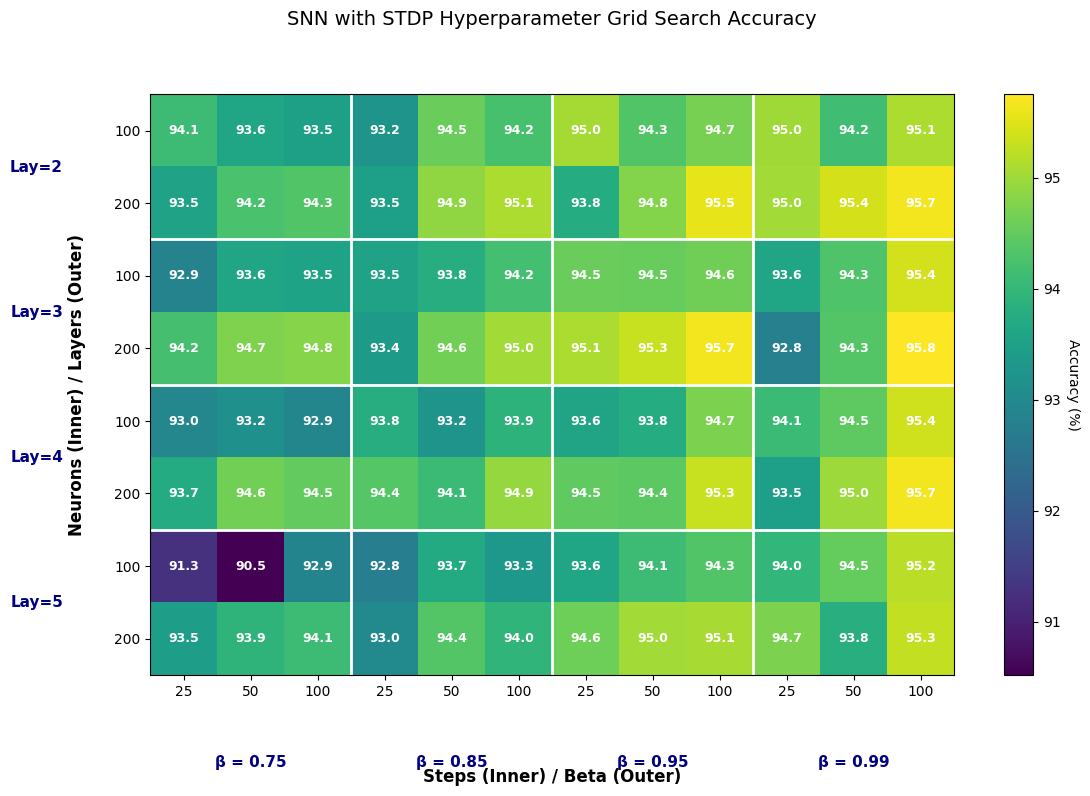

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
data_4d = np.array(accuracy_rec).reshape(len(betas), len(step_nums), len(layer_nums), len(neuron_nums))

# Step B: Permute dimensions to put Y-axis attributes first, then X-axis attributes.
# We want: (Layer, Neuron) on vertical, (Beta, Step) on horizontal.
# Current indices: 0:Beta, 1:Step, 2:Layer, 3:Neuron
# Desired indices: 2:Layer, 3:Neuron, 0:Beta, 1:Step
data_permuted = data_4d.transpose(2, 3, 0, 1)

data_matrix = data_permuted.reshape(8, 12)

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(12, 8))

# Draw the heatmap
im = ax.imshow(data_matrix, cmap='viridis', aspect='auto')

# Add Colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Accuracy (%)", rotation=-90, va="bottom")

# 4. ADD TEXT ANNOTATIONS (The values inside the squares)
for i in range(data_matrix.shape[0]):
    for j in range(data_matrix.shape[1]):
        text = ax.text(j, i, f"{data_matrix[i, j]:.1f}",
                       ha="center", va="center", color="w", fontsize=9, fontweight='bold')

# 5. CONFIGURE X-AXIS (Beta / Step)
# Inner Labels (Steps)
ax.set_xticks(np.arange(12))
ax.set_xticklabels(step_nums * 4)
ax.set_xlabel("Steps (Inner) / Beta (Outer)", labelpad=50, fontweight='bold', fontsize=12)

# Outer Labels (Betas) - Manually placed
for i, b in enumerate(betas):
    # Calculate center position for the group of 3 columns
    center_x = (i * 3) + 1 
    # Place text slightly below the X-axis (y = 8.2 in axis coordinates)
    ax.text(center_x, 8.6, f"β = {b}", ha='center', va='top', fontsize=11, fontweight='bold', color='navy')
    
    # Draw vertical separator lines
    if i > 0:
        ax.axvline(x=(i * 3) - 0.5, color='white', linewidth=2)

# 6. CONFIGURE Y-AXIS (Layer / Neuron)
# Inner Labels (Neurons)
ax.set_yticks(np.arange(8))
ax.set_yticklabels(neuron_nums * 4)
ax.set_ylabel("Neurons (Inner) / Layers (Outer)", labelpad=20, fontweight='bold', fontsize=12)

# Outer Labels (Layers) - Manually placed
for i, l in enumerate(layer_nums):
    # Calculate center position for the group of 2 rows
    center_y = (i * 2) + 0.5
    # Place text slightly to the left of Y-axis (x = -1.2)
    ax.text(-1.8, center_y, f"Lay={l}", ha='right', va='center', fontsize=11, fontweight='bold', color='navy')
    
    # Draw horizontal separator lines
    if i > 0:
        ax.axhline(y=(i * 2) - 0.5, color='white', linewidth=2)

# Adjust layout to make room for the outer labels
plt.title("SNN with STDP Hyperparameter Grid Search Accuracy", pad=50, fontsize=14)
plt.tight_layout()
plt.subplots_adjust(left=0.15, bottom=0.15) # Add extra margin for outer labels

plt.show()

In [5]:
class ASPSTDP_SNN:
    """
    Adaptive Synaptic Plasticity (ASP) rule.
    Updates a given weight matrix W in-place (shape: [out_features, in_features]).
    Implements a Recovery Phase (STDP) and a Decay Phase (Adaptive Leak).
    """
    def __init__(
        self,
        weight: torch.Tensor,
        tau_rec: float = 4.0,     # [UPDATED] Recent pre-trace decay
        tau_acc: float = 40.0,    # [UPDATED] Accumulative pre-trace decay
        tau_post: float = 80.0,   # [UPDATED] Post-trace decay
        offset: float = 0.2,      # [UPDATED] Controls depression threshold
        lr: float = 0.01,         # [UPDATED] Combined k1_const * k_const from paper
        k2_const: float = 100.0,  # [UPDATED] Multiplier for leak time constant
        alpha: float = 0.01,      # [UPDATED] Exponential decay rate
        v_thresh: float = 1.0,    # Baseline membrane threshold of neurons
        theta_inc: float = 0.05,  # Homeostatic threshold increment per spike
        tau_theta: float = 1000.0,# Homeostatic threshold decay
        wmin: float | None = 0.0, # Good practice to bound ASP to non-negative
        wmax: float | None = 1.0,
        dt: float = 1.0, 
    ):
        self.W = weight
        
        # ASP Hyperparameters from Table 1
        self.offset = offset
        self.lr = lr
        self.k2_const = k2_const
        self.alpha = alpha
        self.v_thresh = v_thresh
        self.theta_inc = theta_inc
        self.wmin = wmin
        self.wmax = wmax

        # Exponential decay multipliers
        self.decay_rec = math.exp(-dt / tau_rec)
        self.decay_acc = math.exp(-dt / tau_acc)
        self.decay_post = math.exp(-dt / tau_post)
        self.decay_theta = math.exp(-dt / tau_theta)

        # Traces initialization
        self.pre_rec = None   # (B, in_features)
        self.pre_acc = None   # (B, in_features)
        self.post_trace = None# (B, out_features)
        self.theta = None     # (B, out_features) - Homeostasis tracking

    def reset_state(self):
        """Reset traces at the beginning of a new sequence."""
        self.pre_rec = None
        self.pre_acc = None
        self.post_trace = None
        self.theta = None

    @torch.no_grad()
    def step(self, pre_spk: torch.Tensor, post_spk: torch.Tensor):
        B, in_features = pre_spk.shape
        _, out_features = post_spk.shape
        device = pre_spk.device
        dtype = self.W.dtype

        # 1. Initialize states if none exist
        if self.pre_rec is None:
            self.pre_rec = torch.zeros((B, in_features), device=device, dtype=dtype)
            self.pre_acc = torch.zeros((B, in_features), device=device, dtype=dtype)
            self.post_trace = torch.zeros((B, out_features), device=device, dtype=dtype)
            self.theta = torch.zeros((B, out_features), device=device, dtype=dtype)

        pre = pre_spk.to(dtype)
        post = post_spk.to(dtype)

        # -------------------------------------------------------------
        # PART A: UPDATE TRACES (Eqn. 6)
        # -------------------------------------------------------------
        
        # Recent pre-trace: Decays, but sets strictly to 1.0 on spike
        self.pre_rec.mul_(self.decay_rec)
        self.pre_rec[pre > 0] = 1.0 
        
        # Accumulative pre-trace: Decays, and adds 1.0 on spike
        self.pre_acc.mul_(self.decay_acc).add_(pre)
        
        # Post-trace: Decays, and adds 1.0 on spike
        self.post_trace.mul_(self.decay_post).add_(post)
        
        # Homeostasis (Theta): Decays, adds increment on post-spike
        self.theta.mul_(self.decay_theta).add_(post * self.theta_inc)

        # -------------------------------------------------------------
        # PART B: DECAY PHASE / ADAPTIVE LEAK (Eqn. 8)
        # -------------------------------------------------------------
        # tau_leak = k2_const * (Post + 1) * 2^(V_thresh + theta)
        tau_leak = self.k2_const * (self.post_trace + 1.0) * torch.pow(2.0, self.v_thresh + self.theta)
        
        # Average tau_leak over the batch to apply to the weight matrix
        # Shape becomes (out_features, 1) so it broadcasts over in_features
        tau_leak_mean = tau_leak.mean(dim=0).unsqueeze(1)
        
        # Apply Exponential Decay Phase to ALL weights (W = W - (alpha/tau_leak) * W)
        self.W.sub_((self.alpha / tau_leak_mean) * self.W)

        # -------------------------------------------------------------
        # PART C: RECOVERY PHASE / STDP (Eqn. 7)
        # -------------------------------------------------------------
        # Weight changes ONLY when post-neuron spikes.
        # dW = (lr / (Post + 1)) * (Pre_rec - offset) * (1 / 2^Pre_acc)
        
        # 1. Calculate the Post-neuron factor: (lr / (Post + 1)) * post_spk
        post_factor = (self.lr / (self.post_trace + 1.0)) * post  # Shape: (B, out_features)
        
        # 2. Calculate the Pre-neuron factor: (Pre_rec - offset) * (1 / 2^Pre_acc)
        pre_factor = (self.pre_rec - self.offset) * (1.0 / torch.pow(2.0, self.pre_acc)) # Shape: (B, in_features)
        
        # 3. Matrix multiply to align features and sum over the batch
        dW = post_factor.T @ pre_factor  # Shape: (out_features, in_features)
        
        # 4. Average over batch and apply
        self.W.add_(dW / B)

        # Apply bounds if specified
        if self.wmin is not None or self.wmax is not None:
            lo = self.wmin if self.wmin is not None else -float("inf")
            hi = self.wmax if self.wmax is not None else float("inf")
            self.W.clamp_(lo, hi)
            
            
class SNN_ASP(nn.Module):
    def __init__(self, layer_num, beta, step_num, hidden_num, num_inputs, num_outputs,
                 asp_lr=0.01, tau_rec=4.0, tau_acc=40.0, tau_post=80.0, 
                 offset=0.2, k2_const=100.0, alpha=0.01, wmin=0.0, wmax=1.0):
        super().__init__()
        self.layer_num = layer_num
        self.beta = beta
        self.step_num = step_num
        self.hidden_num = hidden_num

        # 1. Initialize Layers
        self.inputFC = nn.Linear(num_inputs, self.hidden_num)
        self.inputLIF = snn.Leaky(beta=self.beta)

        self.innerLayer = nn.ModuleList()
        self.innerLIF = nn.ModuleList()
        for _ in range(layer_num):
            self.innerLayer.append(nn.Linear(self.hidden_num, self.hidden_num))
            self.innerLIF.append(snn.Leaky(beta=self.beta))

        self.outputFC = nn.Linear(self.hidden_num, num_outputs)
        self.outputLIF = snn.Leaky(beta=self.beta)

        # 2. Centralized ASP Tracker
        self.asp_modules = []
        
        # [UPDATED] Dictionary for ASP kwargs based on Table 1
        asp_kwargs = {
            'tau_rec': tau_rec, 'tau_acc': tau_acc, 'tau_post': tau_post, 
            'offset': offset, 'lr': asp_lr, 'k2_const': k2_const, 
            'alpha': alpha, 'wmin': wmin, 'wmax': wmax
        }

        # Add Input ASP
        self.asp_modules.append(ASPSTDP_SNN(self.inputFC.weight, **asp_kwargs))
        
        # Add Inner Layers ASP
        for i in range(layer_num):
            self.asp_modules.append(ASPSTDP_SNN(self.innerLayer[i].weight, **asp_kwargs))
            
        # Add Output ASP
        self.asp_modules.append(ASPSTDP_SNN(self.outputFC.weight, **asp_kwargs))


    def apply_asp(self, all_pre_spks, all_post_spks):
        """
        Loops through the collected spikes and applies ASP layer-by-layer.
        all_pre_spks:  List of tensors, one per layer. Shape: (T, B, in_features)
        all_post_spks: List of tensors, one per layer. Shape: (T, B, out_features)
        """
        with torch.no_grad():
            for layer_idx, asp_mod in enumerate(self.asp_modules):
                # Reset traces at the start of a new sequence/batch
                asp_mod.reset_state()
                
                pre_seq = all_pre_spks[layer_idx]
                post_seq = all_post_spks[layer_idx]
                
                # Apply ASP step-by-step through time
                for t in range(pre_seq.size(0)):
                    asp_mod.step(pre_seq[t], post_seq[t])


    def forward(self, x):
        # [Your forward pass remains exactly the same as the previous STDP version]
        
        mem_in = self.inputLIF.init_leaky()
        mem_hidden = [layer.init_leaky() for layer in self.innerLIF]
        mem_out = self.outputLIF.init_leaky()

        total_weight_layers = self.layer_num + 2 
        
        pre_spk_rec = [[] for _ in range(total_weight_layers)]
        post_spk_rec = [[] for _ in range(total_weight_layers)]
        
        spk_out_rec = []
        mem_out_rec = []

        for _ in range(self.step_num):
            layer_idx = 0
            
            # --- INPUT LAYER ---
            pre_spk_rec[layer_idx].append(x)  
            
            cur = self.inputFC(x)
            spk_in, mem_in = self.inputLIF(cur, mem_in)
            
            post_spk_rec[layer_idx].append(spk_in) 
            prev_spk = spk_in
            layer_idx += 1

            # --- INNER LAYERS ---
            for idx in range(self.layer_num):
                pre_spk_rec[layer_idx].append(prev_spk)
                
                cur = self.innerLayer[idx](prev_spk)
                spk_hid, mem_hidden[idx] = self.innerLIF[idx](cur, mem_hidden[idx])
                
                post_spk_rec[layer_idx].append(spk_hid)
                prev_spk = spk_hid
                layer_idx += 1

            # --- OUTPUT LAYER ---
            pre_spk_rec[layer_idx].append(prev_spk)
            
            cur = self.outputFC(prev_spk)
            spk_out, mem_out = self.outputLIF(cur, mem_out)
            
            post_spk_rec[layer_idx].append(spk_out)

            spk_out_rec.append(spk_out)
            mem_out_rec.append(mem_out)

        stacked_pre_spks = [torch.stack(seq, dim=0) for seq in pre_spk_rec]
        stacked_post_spks = [torch.stack(seq, dim=0) for seq in post_spk_rec]

        return (
            torch.stack(spk_out_rec, dim=0),
            torch.stack(mem_out_rec, dim=0),
            stacked_pre_spks,
            stacked_post_spks
        )

In [6]:
# betas = [0.75, 0.85, 0.95, 0.99]
# layer_nums = [2, 3, 4, 5]
# neuron_nums = [100, 200]
# step_nums = [25, 50, 100]
betas = [0.99]
layer_nums = [5]
neuron_nums = [100]
step_nums = [20]

accuracy_rec = []

for b in betas:
  for sn in step_nums:
    for ln in layer_nums:
      for n in neuron_nums:

        net = SNN_ASP(
            layer_num=ln, beta=b, step_num=sn, hidden_num=n,
            num_inputs=28*28, num_outputs=10,
            asp_lr=1e-4
        ).to(device)

        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))

        num_epochs = 1
        loss_hist = []
        test_loss_hist = []
        counter = 0

        # Outer training loop
        for epoch in range(num_epochs):
          iter_counter = 0

          # Minibatch training loop
          for data, targets in train_loader:
            data = data.to(device)
            targets = targets.to(device)

            # forward pass
            net.train()
            spk_out_rec, mem_out_rec, all_pre_spks, all_post_spks = net(data.view(data.size(0), -1))

            # loss summed over time
            loss_val = torch.zeros((1), dtype=dtype, device=device)
            for step in range(sn):
              loss_val += loss_fn(mem_out_rec[step], targets)

            # supervised update
            optimizer.zero_grad(set_to_none=True)
            loss_val.backward()
            

            # STDP update (local plasticity)
            net.apply_asp(all_pre_spks, all_post_spks)
            optimizer.step()

            # Store loss history for future plotting
            loss_hist.append(loss_val.item())

            # Test minibatch
            with torch.no_grad():
              net.eval()
              test_data, test_targets = next(iter(test_loader))
              test_data = test_data.to(device)
              test_targets = test_targets.to(device)

              test_spk_out, test_mem_out, _, _ = net(test_data.view(test_data.size(0), -1))

              test_loss = torch.zeros((1), dtype=dtype, device=device)
              for step in range(sn):
                test_loss += loss_fn(test_mem_out[step], test_targets)
              test_loss_hist.append(test_loss.item())

              if counter % 50 == 0:
                train_printer(
                  data, targets, epoch,
                  counter, iter_counter,
                  loss_hist, test_loss_hist,
                  test_data, test_targets
                )

              counter += 1
              iter_counter += 1

        #Final full test accuracy
        total = 0
        correct = 0

        # drop_last switched to False to keep all samples
        test_loader_full = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=False)

        with torch.no_grad():
          net.eval()
          for data, targets in test_loader_full:
            data = data.to(device)
            targets = targets.to(device)

            test_spk_out, _, _, _ = net(data.view(data.size(0), -1))

            # spike-count readout
            _, predicted = test_spk_out.sum(dim=0).max(1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

        print(f"Total correctly classified test set images: {correct}/{total}")
        print(f"Test Set Accuracy: {100 * correct / total:.2f}%")
        accuracy_rec.append(100 * correct / total)

Epoch 0, Iteration 0
Train Set Loss: 48.49
Test Set Loss: 103.42
Train set accuracy for a single minibatch: 5.47%
Test set accuracy for a single minibatch: 14.84%


Epoch 0, Iteration 50
Train Set Loss: 46.54
Test Set Loss: 46.75
Train set accuracy for a single minibatch: 7.81%
Test set accuracy for a single minibatch: 9.38%


Epoch 0, Iteration 100
Train Set Loss: 45.72
Test Set Loss: 45.62
Train set accuracy for a single minibatch: 13.28%
Test set accuracy for a single minibatch: 10.16%


Epoch 0, Iteration 150
Train Set Loss: 46.02
Test Set Loss: 45.87
Train set accuracy for a single minibatch: 8.59%
Test set accuracy for a single minibatch: 7.81%


Epoch 0, Iteration 200
Train Set Loss: 45.98
Test Set Loss: 46.25
Train set accuracy for a single minibatch: 10.16%
Test set accuracy for a single minibatch: 7.81%


Epoch 0, Iteration 250
Train Set Loss: 46.97
Test Set Loss: 47.02
Train set accuracy for a single minibatch: 10.16%
Test set accuracy for a single minibatch: 14.06%


Epoch 